# Scalar Chebyshev2 vs Trapezoid Integration

This notebook reproduces the scalar noisy integration comparison on `[0, 1]`. The Chebyshev path is implemented in the reusable library code and calls `gtsam.Chebyshev2` directly for the pseudo-spectral fit and quadrature weights. The trapezoid baseline is local NumPy code because this is not provided by GTSAM.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "python").exists():
    repo_root = repo_root.parent
python_dir = repo_root / "python"
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from imuFactors.quadrature import (
    ScalarFunction,
    plot_fixed_node_comparison,
    plot_function_noise_comparison,
    run_scalar_monte_carlo,
)

plt.rcParams.update({"figure.dpi": 120})

In [2]:
INTERVAL = (0.0, 1.0)
FUNCTIONS = [
    ScalarFunction(
        name="tanh(t)",
        value=lambda t: np.tanh(t),
        antiderivative=lambda t: np.log(np.cosh(t)),
    ),
    ScalarFunction(
        name="sin(2*pi*t)",
        value=lambda t: np.sin(2.0 * np.pi * t),
        antiderivative=lambda t: (1.0 - np.cos(2.0 * np.pi * t)) / (2.0 * np.pi),
    ),
    ScalarFunction(
        name="pi*t^(31/4)",
        value=lambda t: np.pi * t ** (31.0 / 4.0),
        antiderivative=lambda t: np.pi * t ** (35.0 / 4.0) / (35.0 / 4.0),
    ),
]

SAMPLE_COUNTS = np.arange(5, 49)
CHEBYSHEV_NODES = np.arange(2, 25)
FIXED_NODES = [2, 9, 17, 24]
NOISE_FRACTIONS = np.array([
    0.0, 0.025, 0.05, 0.06, 0.075, 0.10,
    0.12, 0.15, 0.17, 0.20, 0.225,
])
SELECTED_NOISE_FRACTIONS = [0.06, 0.12, 0.17, 0.225]
NUM_SEEDS = 100
RANDOM_SEED = 20260523
EVALUATION_COUNT = 151

In [3]:
result = run_scalar_monte_carlo(
    FUNCTIONS,
    sample_counts=SAMPLE_COUNTS,
    chebyshev_node_counts=CHEBYSHEV_NODES,
    noise_fractions=NOISE_FRACTIONS,
    num_seeds=NUM_SEEDS,
    seed=RANDOM_SEED,
    interval=INTERVAL,
    evaluation_count=EVALUATION_COUNT,
)

method_metrics = result.method_metrics
comparisons = result.comparisons
comparisons.head()

,function,noise_fraction,noise_std,sample_count,chebyshev_nodes,end_error,rmse_error,max_error
0,tanh(t),0.000,0.00000,5,2,0.009990,0.007820,0.012765
1,tanh(t),0.000,0.00000,5,3,-0.002674,-0.000766,-0.001718
2,tanh(t),0.000,0.00000,5,4,-0.002674,-0.001377,-0.002673
3,tanh(t),0.000,0.00000,5,5,-0.003018,-0.001588,-0.003018
4,tanh(t),0.025,0.01904,5,2,0.005050,0.004567,0.007102


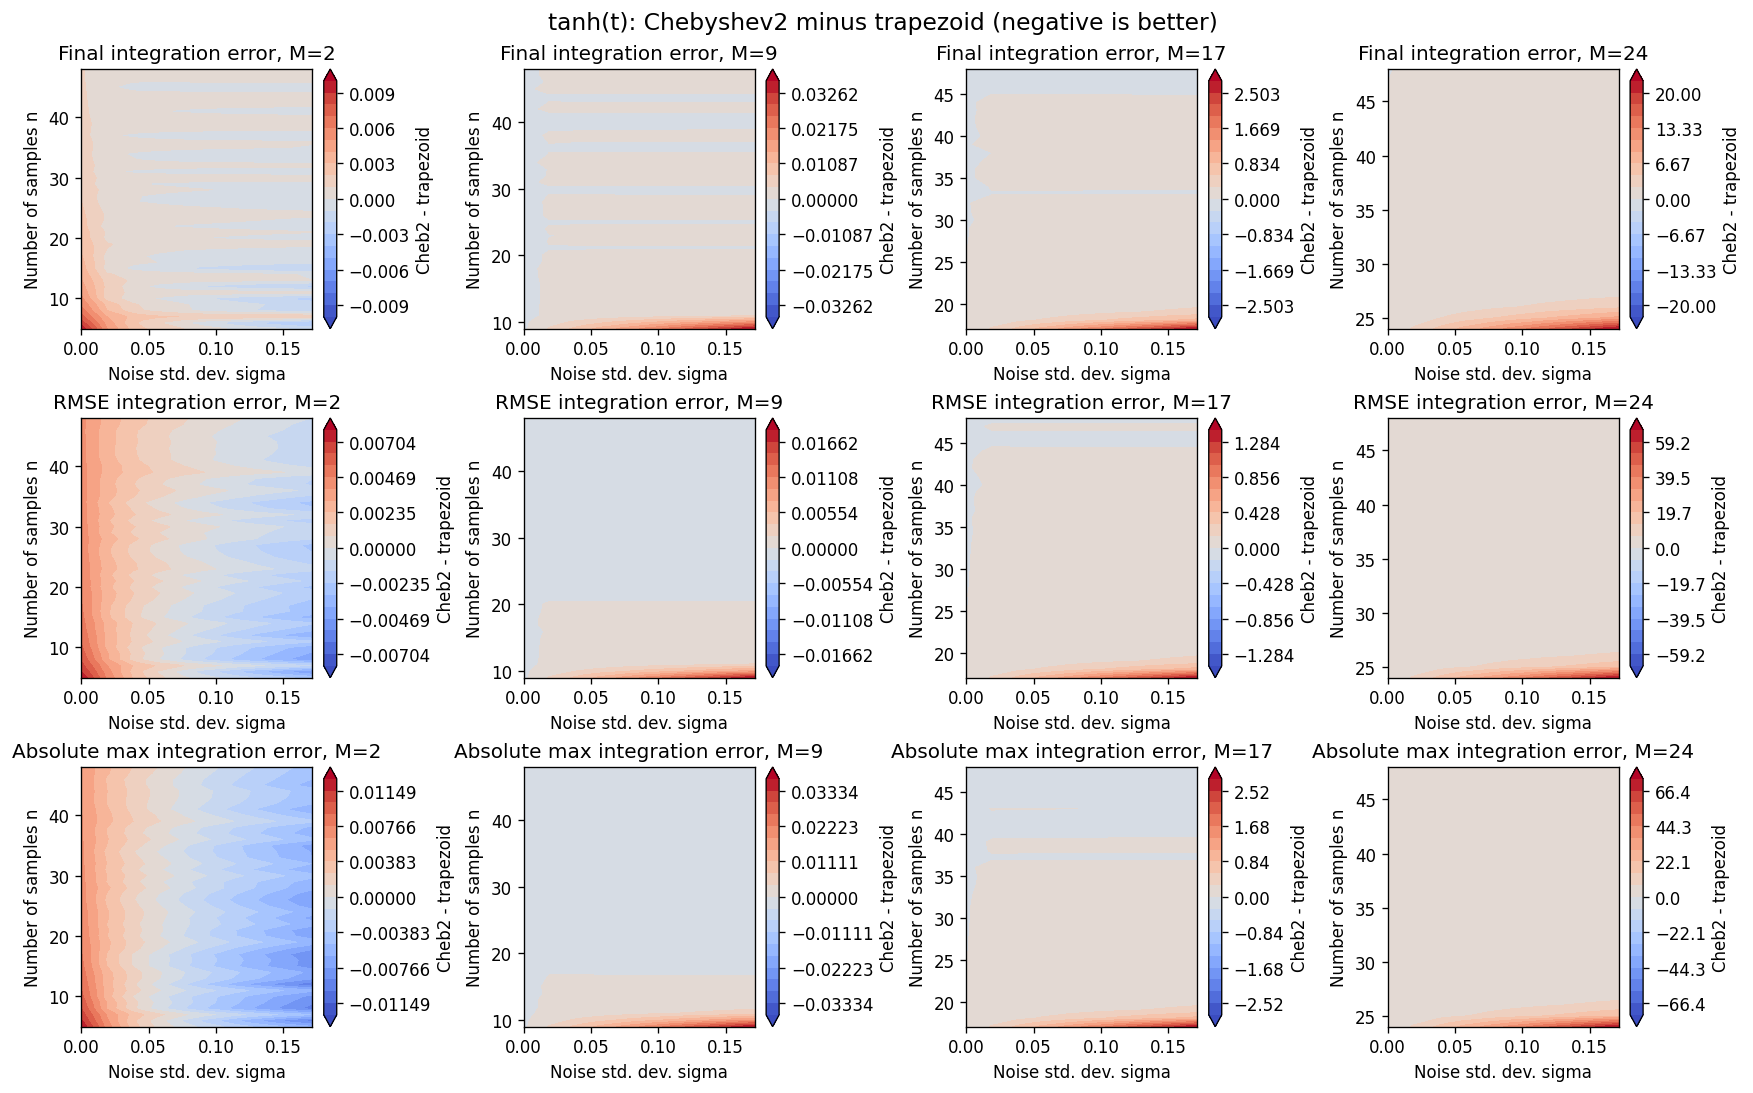

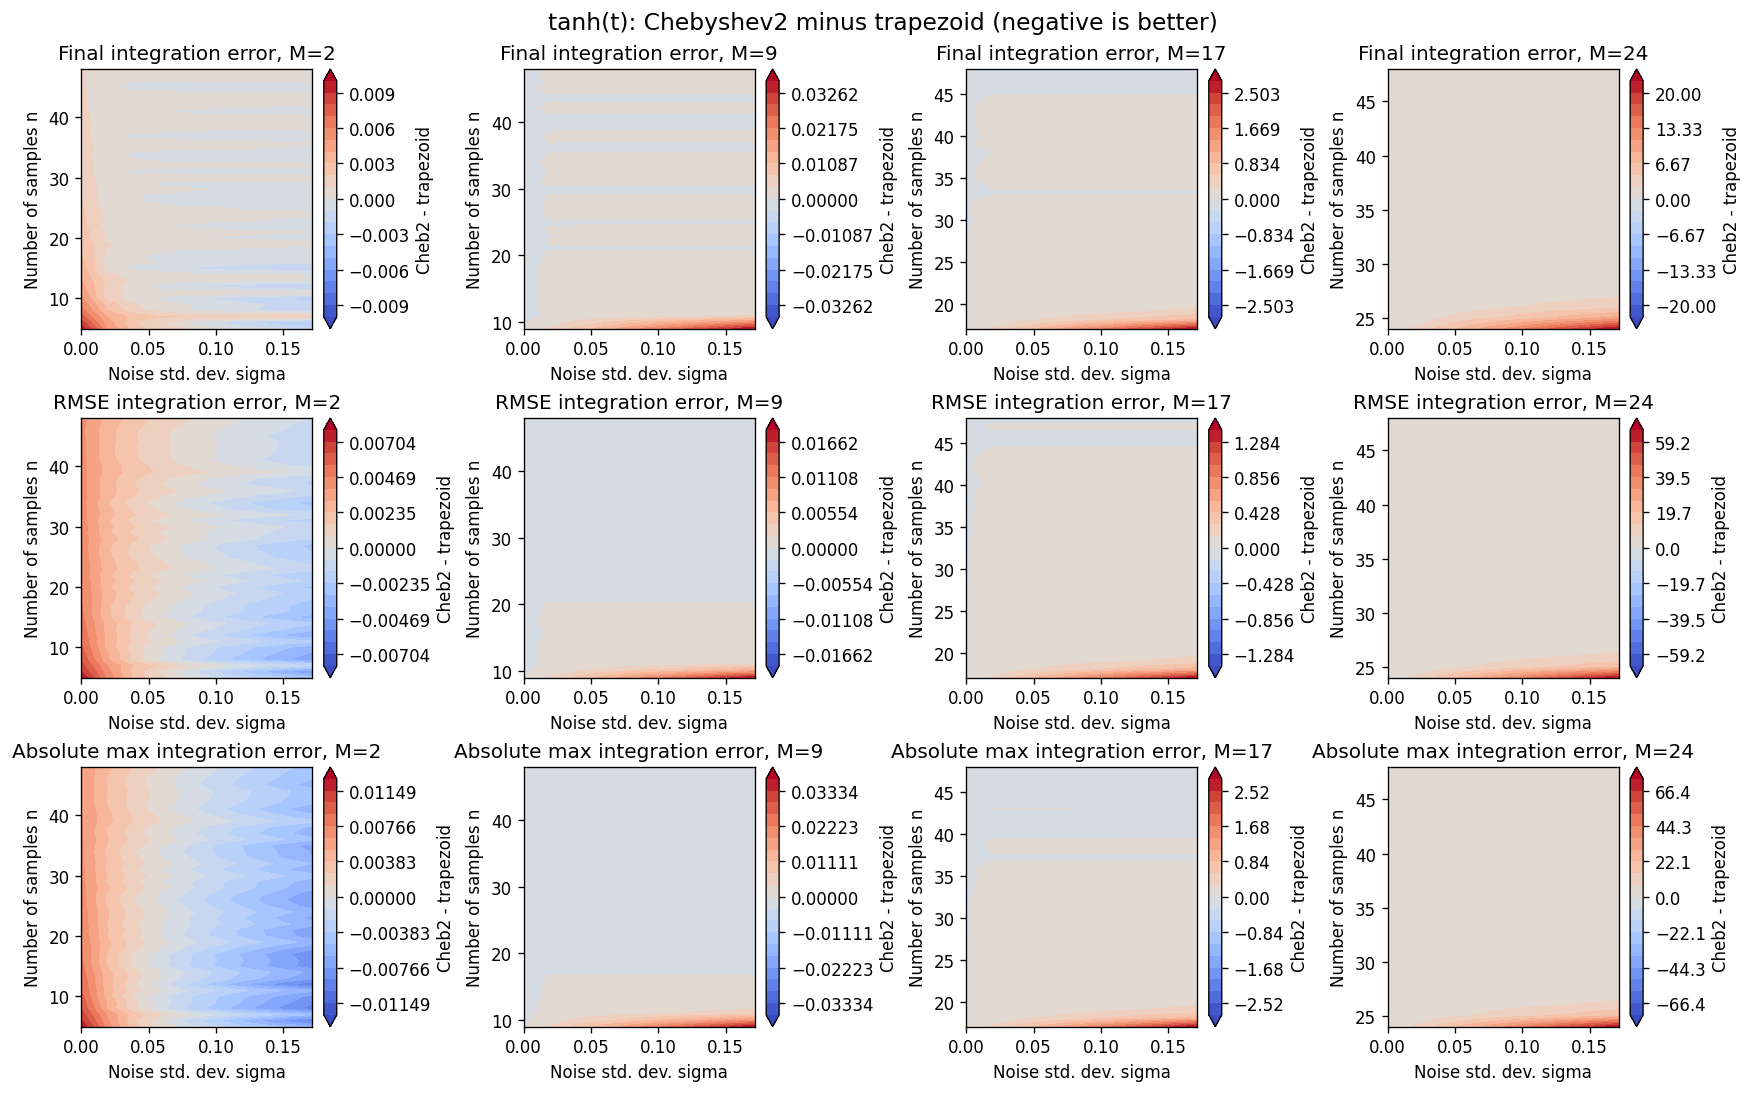

In [4]:
fig = plot_fixed_node_comparison(
    comparisons,
    function_name="tanh(t)",
    selected_nodes=FIXED_NODES,
)
fig

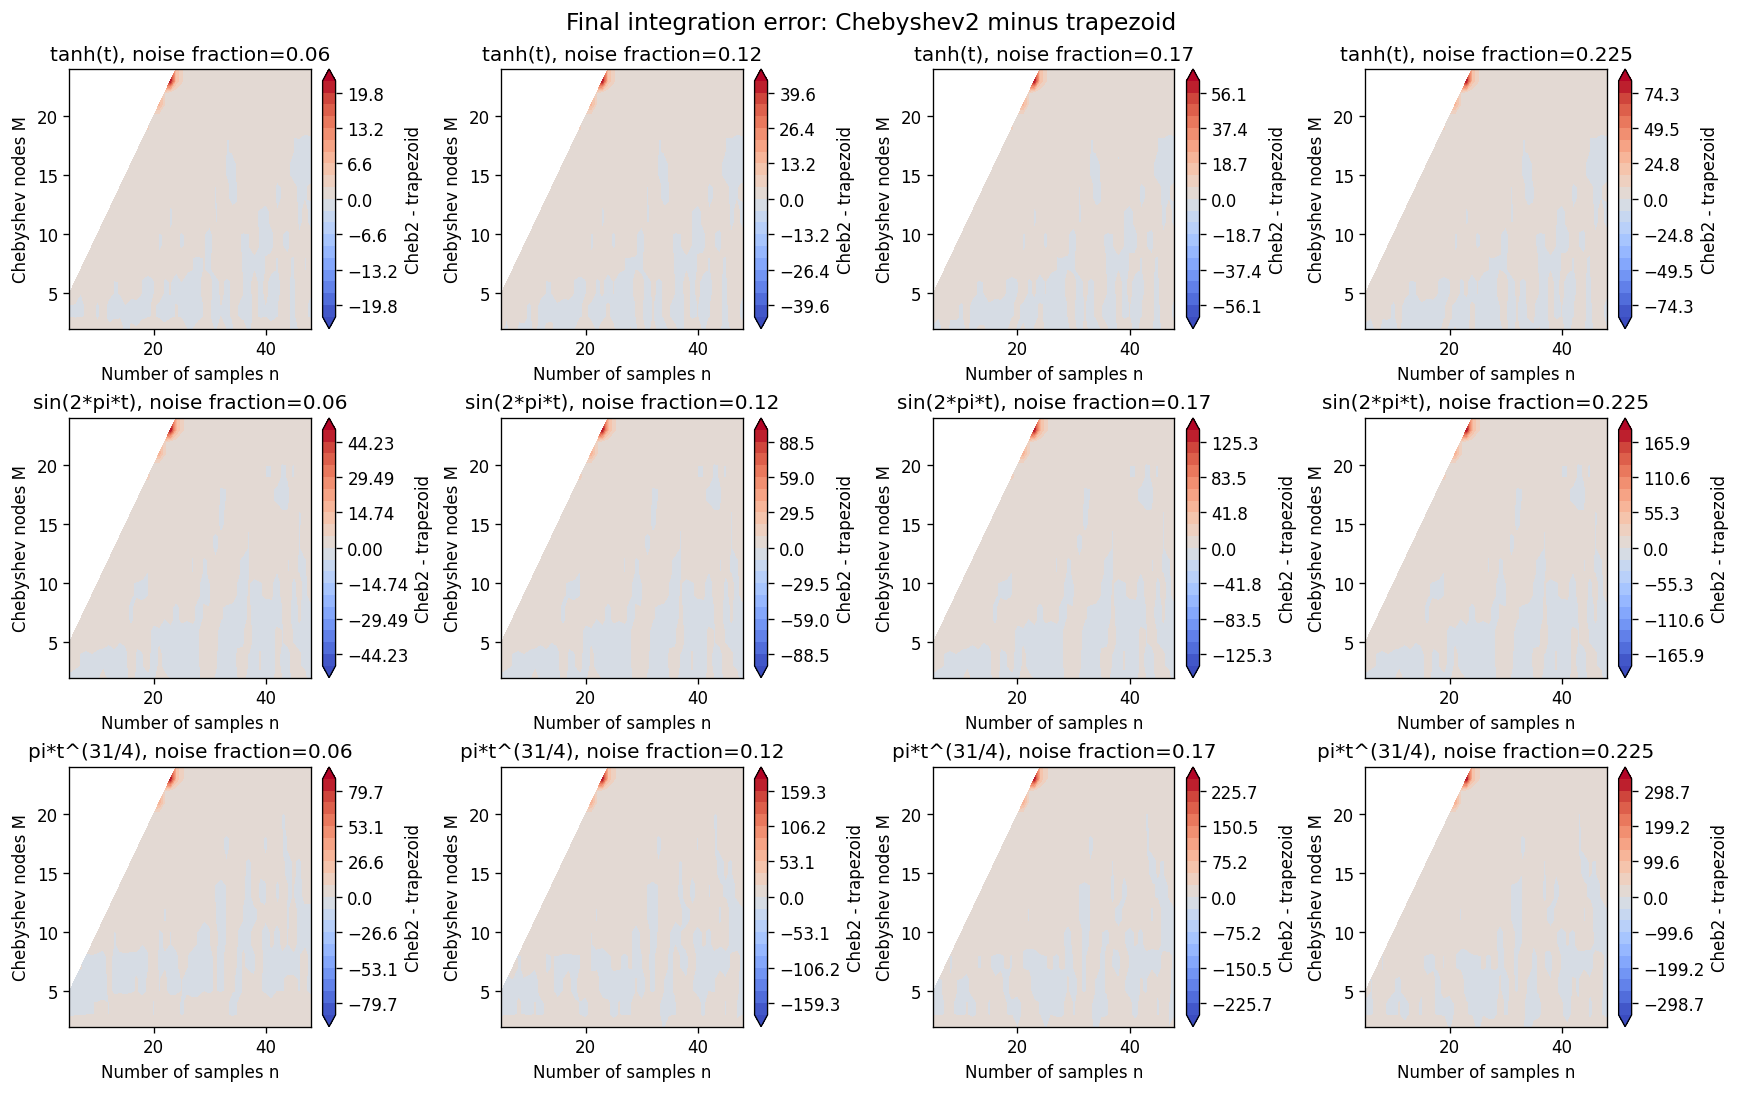

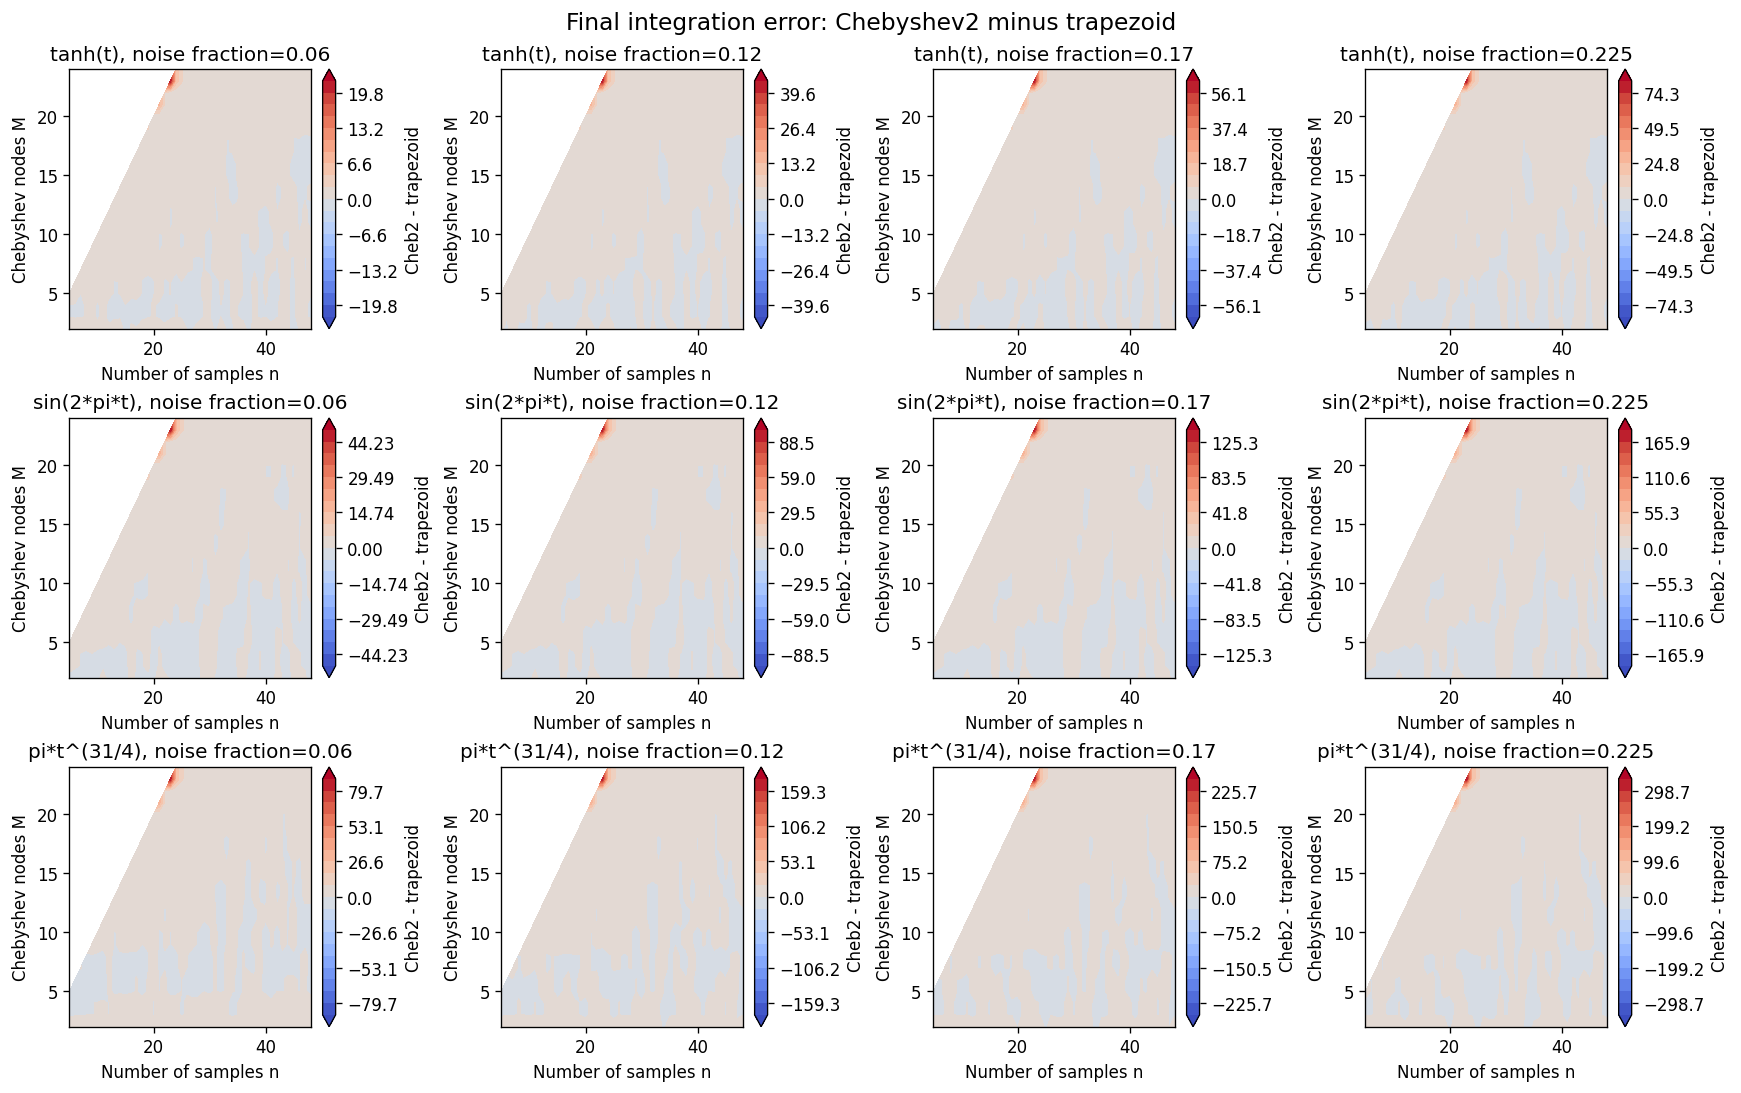

In [5]:
fig = plot_function_noise_comparison(
    comparisons,
    function_names=[function.name for function in FUNCTIONS],
    selected_noise_fractions=SELECTED_NOISE_FRACTIONS,
    metric="end_error",
)
fig

In [6]:
summary = (
    comparisons.groupby("function")[["end_error", "rmse_error", "max_error"]]
    .agg(["min", "median", "max"])
)
summary

end_error                       rmse_error                        \
                  min    median         max        min    median         max   
function                                                                       
pi*t^(31/4) -0.114374  0.000703  331.931252  -0.031653  0.000557  292.862944   
sin(2*pi*t) -0.011882  0.000217  184.298203  -0.023141  0.000403  185.248414   
tanh(t)     -0.003526  0.000106   82.513168  -0.004830  0.000005   65.759342   

            max_error                        
                  min    median         max  
function                                     
pi*t^(31/4) -0.111063 -0.000344  334.084892  
sin(2*pi*t) -0.039972 -0.000005  210.429592  
tanh(t)     -0.010064 -0.000126   82.987735